In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("whitegrid")

In [4]:
data = 'mousebrain_revised'
basis = 'spatial'
metric_names = ['velocity_consistency', 'spatial_velo_consist']
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']
results = {}
for model in models:
    model_name = model if model != 'scvelo' else 'scvelo_dynamical'
    result = {}
    for metric_name in metric_names:
        metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pd.read_pickle(f)
        result[metric_name] = metric
    results[model] = result
    if model == 'stt':
        result = {}
        for metric_name in metric_names:
            stt_metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                metric = pd.read_pickle(f)
            result[metric_name] = metric
        results['stt_vj'] = result
results

{'scvelo': {'velocity_consistency': [0.847546433880056,
   0.7118078835959477,
   0.8518242780465196,
   0.7828767060761993,
   0.9200274845087938,
   0.8102485223018554,
   0.6105141303331567,
   0.790726887442524,
   0.9041405707759008,
   0.7937173701906606,
   0.654739051103873,
   0.7182081539837206,
   0.5768986990647506,
   0.755697754003554,
   0.8006226545288082,
   0.8088600992687258,
   0.721818421073083,
   0.7027775481408438,
   0.7656937744790616,
   0.7737734262331231,
   0.6934410330894868,
   0.7213875137855774,
   0.9027933694306511,
   0.9709467415035252,
   0.9026823581135305,
   0.9372370595635399,
   0.8918535841257674,
   0.8728578900976771,
   0.746592262634968,
   0.954661926780176,
   0.9159217230280453,
   0.8899376580424434,
   0.8946729778485505,
   0.952238819160178,
   0.8521731189273792,
   0.8921659788161587,
   0.8112223170845502,
   0.912933437842185,
   0.8628767248020435,
   0.9376881989493308,
   0.9416621825699808,
   0.607096618391702,
   0.94614

In [9]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo_avg": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt_vj": "#cd8c95"
}

In [10]:
import os
save_dir = f'../results/results_0128/{data}/metrics'
os.makedirs(save_dir, exist_ok=True)

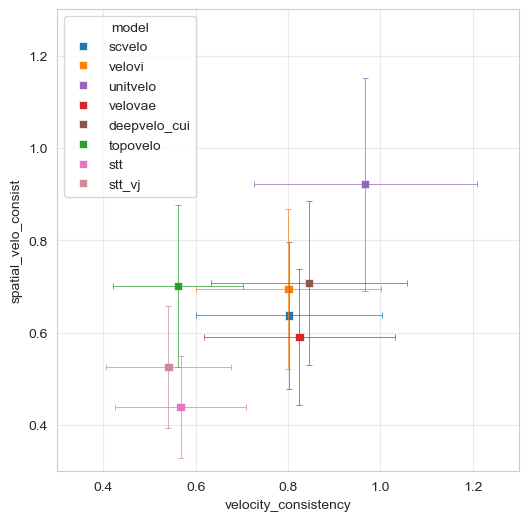

In [26]:
import numpy as np
keys = []
velocity_consistency_means = []
spatial_velo_consist_means = []
velocity_consistency_stds = []
spatial_velo_consist_stds = []
for key, value in results.items():
    keys.append(key)
    velocity_consistency_means.append(np.mean(value['velocity_consistency']))
    spatial_velo_consist_means.append(np.mean(value['spatial_velo_consist']))
    velocity_consistency_stds.append(np.mean(value['velocity_consistency']))
    spatial_velo_consist_stds.append(np.mean(value['spatial_velo_consist']))
df = pd.DataFrame({'model': keys, 'velocity_consistency': velocity_consistency_means, 'spatial_velo_consist': spatial_velo_consist_means})
plt.figure(figsize=(8, 6))
plt.xlim(0.3, 1.3)
plt.ylim(0.3, 1.3)
plt.gca().set_aspect('equal')
sns.scatterplot(data=df, x='velocity_consistency', y='spatial_velo_consist', hue='model', palette=model_colors, marker='s')
for i in range(df.shape[0]):
    plt.errorbar(df['velocity_consistency'][i], df['spatial_velo_consist'][i], xerr=0.25*velocity_consistency_stds[i], yerr=0.25*spatial_velo_consist_stds[i], fmt='none', color=model_colors[df['model'][i]], 
                 capsize=2, capthick=0.5, elinewidth=0.5)
plt.grid(alpha=0.4)
plt.savefig(f'{save_dir}/velocity_consistency_vs_spatial_velo_consist.svg')
plt.show()